# Post-Hoc Explanations vs SENN — FashionMNIST (λ=1e-2, 5 concepts)

This notebook **visualises and compares** three explanation approaches on the same SENN model
trained on FashionMNIST with `robust_reg=1e-2` and `num_concepts=5`.

| Method | Type | Library |
|---|---|---|
| **SENN** (built-in) | Self-explaining (concepts × relevances) | custom |
| **Integrated Gradients** | Post-hoc gradient-based | `captum` |
| **LIME** | Post-hoc perturbation-based | `captum` |

**Pre-requisite:** Run the computation scripts before this notebook:
```bash
python run_integrated_gradients.py --config configs/fashion_mnist_lambda1e-2_c5_seed29.json
python run_lime.py --config configs/fashion_mnist_lambda1e-2_c5_seed29.json
```

**FashionMNIST class labels:**

| 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|
| T-shirt/top | Trouser | Pullover | Dress | Coat | Sandal | Shirt | Sneaker | Bag | Ankle boot |

In [5]:
# ─── Imports & constants ──────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from types import SimpleNamespace
from pathlib import Path

from senn.trainer import SENN_Trainer

plt.style.use('seaborn-v0_8-talk')
%matplotlib inline

FASHION_MNIST_CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

CONFIG_PATH = 'configs/fashion_mnist_lambda1e-2_c5_seed29.json'
EXP_NAME    = 'fashion_mnist_lambda1e-2_c5_seed29'
POSTHOC_DIR = Path('results') / EXP_NAME / 'posthoc'
DEVICE      = 'cuda:0' if torch.cuda.is_available() else 'cpu'

print('Imports OK')

Imports OK


---
## 1. Load SENN model and pre-computed attributions

In [6]:
# ─── Load SENN model ─────────────────────────────────────────────────────────
def load_senn(config_path, device='cpu'):
    with open(config_path, 'r') as f:
        config = json.load(f)
    config['device'] = device
    config['train'] = False
    config = SimpleNamespace(**config)
    checkpoint_path = Path('results') / config.exp_name / 'checkpoints' / 'best_model.pt'
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found at: {checkpoint_path}")
    trainer = SENN_Trainer(config)
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    trainer.model.load_state_dict(checkpoint['model_state'])
    trainer.best_accuracy = checkpoint['best_accuracy']
    trainer.model.eval()
    print(f"SENN loaded — best valid acc: {checkpoint['best_accuracy']*100:.2f}%")
    return trainer

trainer     = load_senn(CONFIG_PATH, device=DEVICE)
model       = trainer.model
test_loader = trainer.test_loader
print(f'Device: {DEVICE}')

Using device cpu
Loading data ...
SENN(
  (conceptizer): ConvConceptizer(
    (encoder): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(10, 5, kernel_size=(5, 5), stride=(1, 1))
        (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (2): ReLU(inplace=True)
      )
      (2): ScalarMapping(
        (layers): ModuleList(
          (0-4): 5 x Linear(in_features=16, out_features=1, bias=True)
        )
      )
    )
    (decoder): ModuleList(
      (0): Sequential(
        (0): ConvTranspose2d(5, 16, kernel_size=(5, 5), stride=(2, 2))
      )
      (1): ReLU(inplace=True)
      (2): Sequential(
        (0): ConvTranspose2d(16, 8, kernel_size=(5, 5), stride=(1, 1))
      )
      (3): ReLU(inplace=True)
      (4): Sequential(
        

In [7]:
# ─── Load pre-computed IG and LIME results ───────────────────────────────────
def load_posthoc(prefix, posthoc_dir):
    """Load attributions, predictions, labels, ablation drops, and meta for a method."""
    attrs  = torch.load(posthoc_dir / f'{prefix}_attributions.pt', map_location='cpu')
    preds  = torch.load(posthoc_dir / f'{prefix}_predictions.pt', map_location='cpu')
    labels = torch.load(posthoc_dir / f'{prefix}_labels.pt', map_location='cpu')
    
    # Carichiamo i nuovi file della metrica relativa (Top, Random e la Differenza)
    drop_top = np.load(posthoc_dir / f'{prefix}_drop_top.npy')
    drop_rand = np.load(posthoc_dir / f'{prefix}_drop_rand.npy')
    drop_relative = np.load(posthoc_dir / f'{prefix}_drop_relative.npy')
    
    with open(posthoc_dir / f'{prefix}_meta.json', 'r') as f:
        meta = json.load(f)
        
    return attrs, preds, labels, drop_top, drop_rand, drop_relative, meta

# Aggiorniamo le tuple per ricevere i nuovi output
ig_attrs, ig_preds, ig_labels, ig_drop_top, ig_drop_rand, ig_drop_relative, ig_meta = load_posthoc('ig', POSTHOC_DIR)
lime_attrs, lime_preds, lime_labels, lime_drop_top, lime_drop_rand, lime_drop_relative, lime_meta = load_posthoc('lime', POSTHOC_DIR)

print(f'IG:   {len(ig_labels)} samples, {ig_meta["total_time_s"]:.1f}s total')
print(f'LIME: {len(lime_labels)} samples, {lime_meta["total_time_s"]:.1f}s total')
print(f"---")
print(f"IG Relative Drop: {ig_drop_relative.mean():.4f}")
print(f"LIME Relative Drop: {lime_drop_relative.mean():.4f}")

IG:   10000 samples, 11.2s total
LIME: 600 samples, 2998.6s total
---
IG Relative Drop: 0.5881
LIME Relative Drop: 0.4579


---
## 2. Select representative samples

One sample per class for qualitative comparison.

In [8]:
# ─── Pick one sample per class from the test set ─────────────────────────────
def get_one_per_class(loader, num_classes=10, device='cpu'):
    examples, labels = {}, {}
    for x, y in loader:
        for i in range(len(y)):
            lab = y[i].item()
            if lab not in examples:
                examples[lab] = x[i]
                labels[lab] = lab
            if len(examples) == num_classes:
                break
        if len(examples) == num_classes:
            break
    imgs = torch.stack([examples[i] for i in range(num_classes)]).to(device)
    labs = torch.tensor([labels[i] for i in range(num_classes)]).to(device)
    return imgs, labs

# We also need to find the indices of these samples in the saved attribution tensors
def find_per_class_indices(all_labels, num_classes=10):
    """Find the index of the first occurrence of each class in the label tensor."""
    indices = {}
    for i, lab in enumerate(all_labels.tolist()):
        if lab not in indices:
            indices[lab] = i
        if len(indices) == num_classes:
            break
    return [indices[c] for c in range(num_classes)]

per_class_imgs, per_class_labs = get_one_per_class(test_loader, device=DEVICE)
pc_indices = find_per_class_indices(ig_labels)

# Slice pre-computed attributions for per-class samples
ig_attr_pc   = ig_attrs[pc_indices]
lime_attr_pc = lime_attrs[pc_indices]
print(f'Per-class sample indices: {pc_indices}')

Per-class sample indices: [19, 2, 1, 13, 6, 8, 4, 9, 18, 0]


---
## 3. SENN built-in explanations

SENN provides concepts $h$ and relevances $\theta$. The prediction is:
$$\hat{y} = \text{softmax}(\theta^\top h)$$

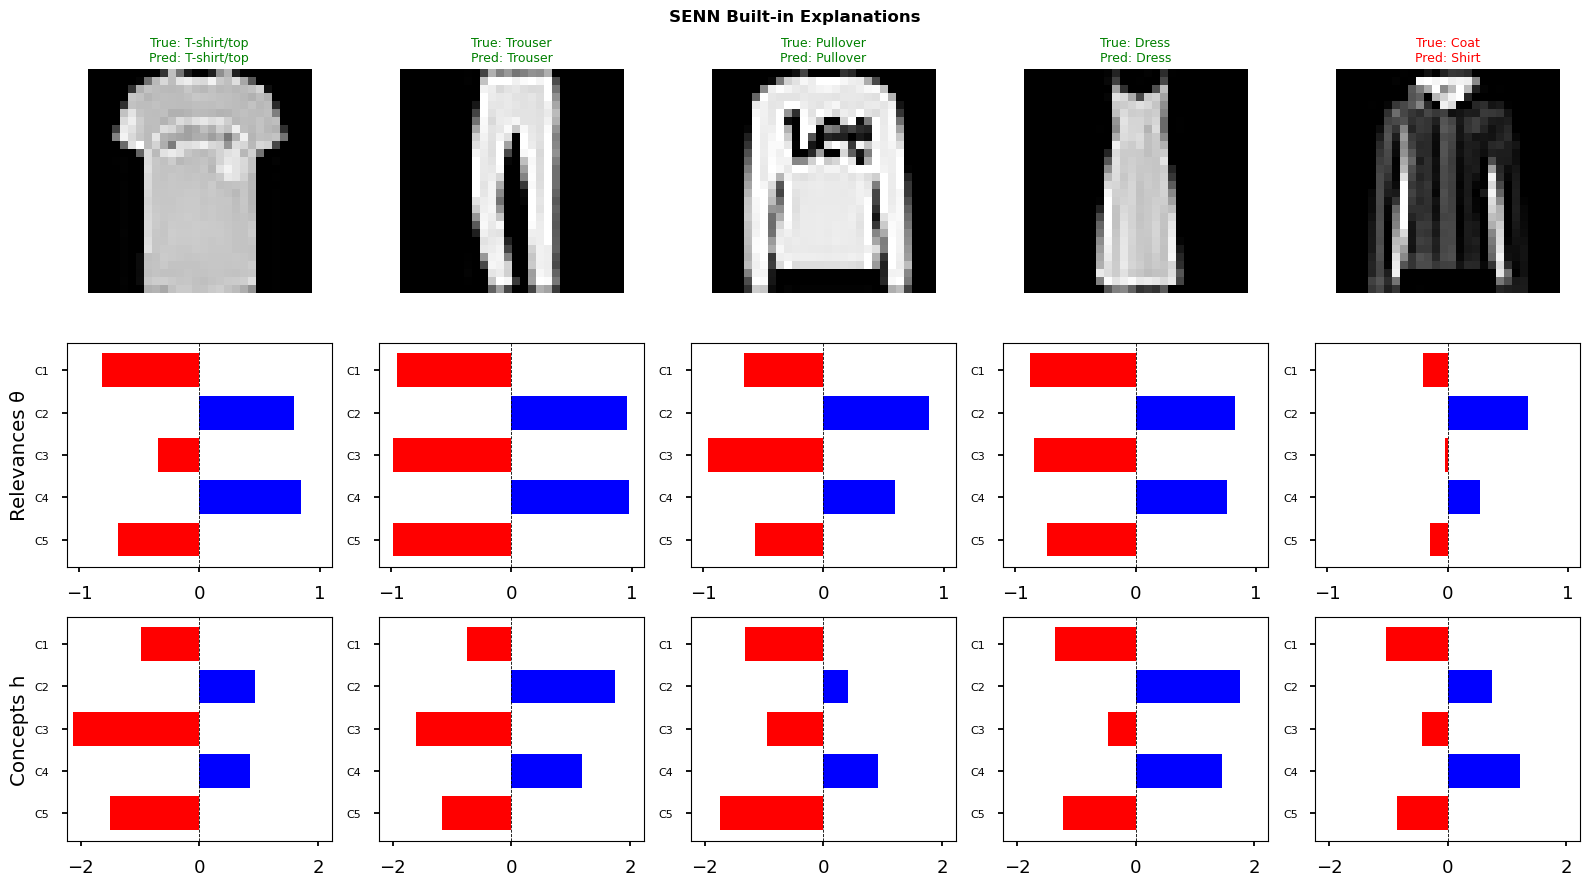

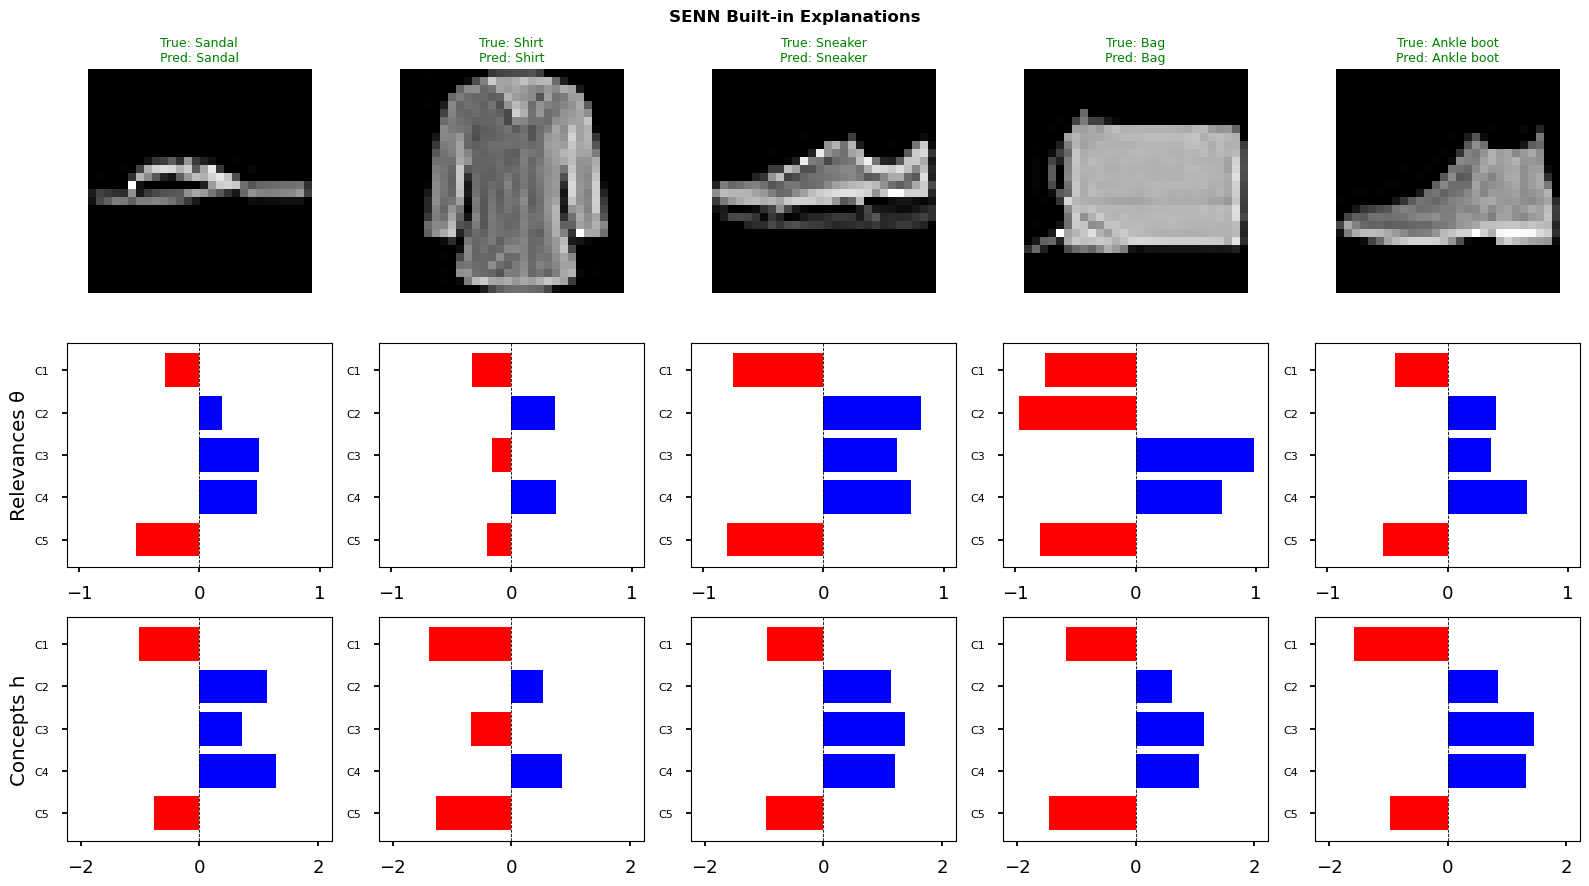

In [9]:
# ─── SENN explanations (live — single forward pass) ──────────────────────────
model.eval()
with torch.no_grad():
    y_pred_pc, (concepts_pc, relevances_pc), _ = model(per_class_imgs)
targets_pc = y_pred_pc.argmax(1)


def plot_senn_explanations(images, y_pred, concepts, relevances, class_names, ncols=5):
    n = len(images)
    pred_idx = y_pred.argmax(1)
    num_concepts = concepts.shape[1]
    concept_lim = max(abs(concepts.min().item()), abs(concepts.max().item())) + 0.1
    y_labels = [f'C{j+1}' for j in range(num_concepts - 1, -1, -1)]
    for g in range((n + ncols - 1) // ncols):
        start = g * ncols
        end = min(start + ncols, n)
        nc = end - start
        fig, axes = plt.subplots(3, nc, figsize=(3.2 * nc, 9))
        if nc == 1:
            axes = axes[:, np.newaxis]
        for col, idx in enumerate(range(start, end)):
            true_lab = class_names[idx] if idx < len(class_names) else '?'
            pred_lab = class_names[pred_idx[idx].item()]
            color = 'green' if true_lab == pred_lab else 'red'
            axes[0, col].imshow(images[idx].squeeze().cpu(), cmap='gray')
            axes[0, col].set_title(f'True: {true_lab}\nPred: {pred_lab}', fontsize=9, color=color)
            axes[0, col].axis('off')
            rs = relevances[idx, :, pred_idx[idx].item()].cpu()
            colors_r = ['b' if v > 0 else 'r' for v in rs.tolist()][::-1]
            axes[1, col].barh(np.arange(num_concepts), np.flip(rs.numpy()), color=colors_r)
            axes[1, col].set_yticks(np.arange(num_concepts))
            axes[1, col].set_yticklabels(y_labels, fontsize=8)
            axes[1, col].set_xlim(-1.1, 1.1)
            axes[1, col].axvline(0, color='k', lw=0.6, ls='--')
            if col == 0:
                axes[1, col].set_ylabel('Relevances \u03b8')
            cs = concepts[idx].flatten().cpu()
            colors_c = ['b' if v > 0 else 'r' for v in cs.tolist()][::-1]
            axes[2, col].barh(np.arange(num_concepts), np.flip(cs.numpy()), color=colors_c)
            axes[2, col].set_yticks(np.arange(num_concepts))
            axes[2, col].set_yticklabels(y_labels, fontsize=8)
            axes[2, col].set_xlim(-concept_lim, concept_lim)
            axes[2, col].axvline(0, color='k', lw=0.6, ls='--')
            if col == 0:
                axes[2, col].set_ylabel('Concepts h')
        plt.suptitle('SENN Built-in Explanations', fontweight='bold')
        plt.tight_layout()
        plt.show()

plot_senn_explanations(per_class_imgs, y_pred_pc, concepts_pc, relevances_pc, FASHION_MNIST_CLASSES)

---
## 4. Integrated Gradients — saliency maps

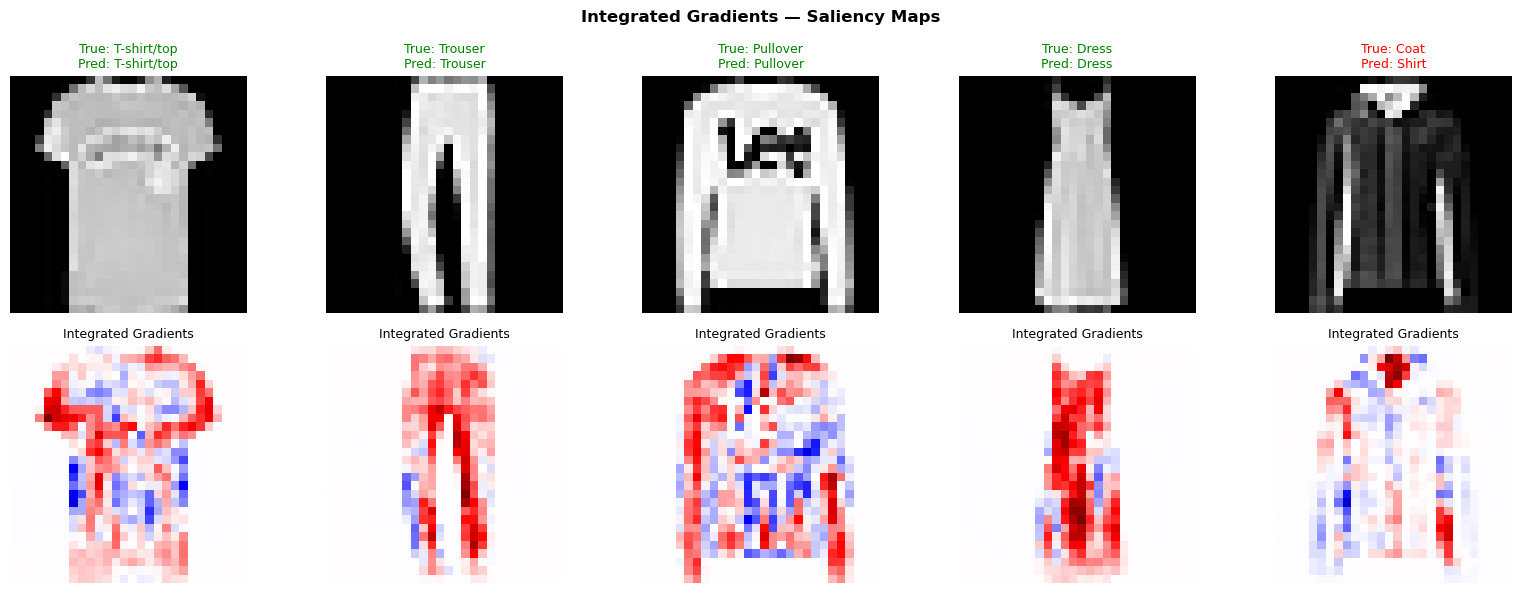

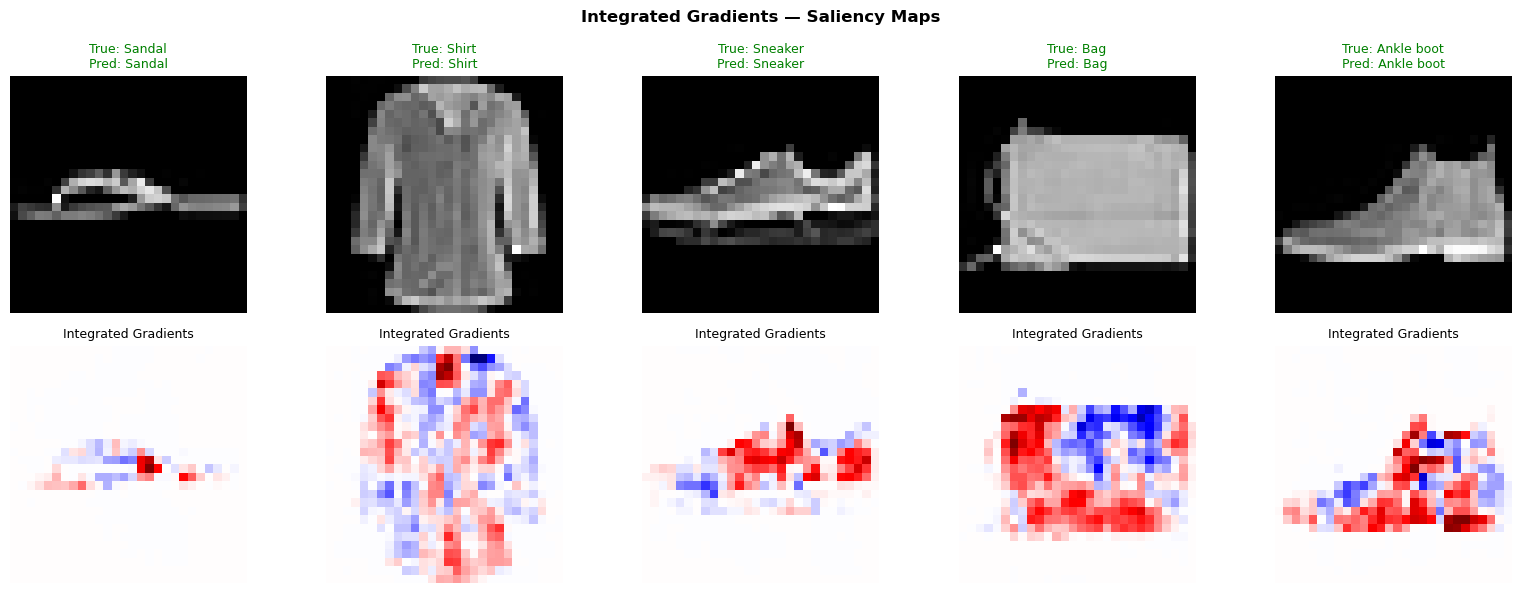

In [10]:
# ─── Visualise IG saliency maps (from pre-computed attributions) ─────────────
def plot_saliency_maps(images, attributions, pred_labels, true_labels,
                       class_names, method_name, ncols=5):
    n = len(images)
    for g in range((n + ncols - 1) // ncols):
        start = g * ncols
        end = min(start + ncols, n)
        nc = end - start
        fig, axes = plt.subplots(2, nc, figsize=(3.2 * nc, 6))
        if nc == 1:
            axes = axes[:, np.newaxis]
        for col, idx in enumerate(range(start, end)):
            true_lab = class_names[true_labels[idx].item()]
            pred_lab = class_names[pred_labels[idx].item()]
            color = 'green' if true_lab == pred_lab else 'red'
            axes[0, col].imshow(images[idx].squeeze().cpu(), cmap='gray')
            axes[0, col].set_title(f'True: {true_lab}\nPred: {pred_lab}', fontsize=9, color=color)
            axes[0, col].axis('off')
            attr = attributions[idx].sum(dim=0).cpu().numpy()
            abs_max = max(abs(attr.min()), abs(attr.max())) + 1e-8
            axes[1, col].imshow(attr, cmap='seismic', vmin=-abs_max, vmax=abs_max)
            axes[1, col].set_title(method_name, fontsize=9)
            axes[1, col].axis('off')
        plt.suptitle(f'{method_name} — Saliency Maps', fontweight='bold')
        plt.tight_layout()
        plt.show()

plot_saliency_maps(per_class_imgs, ig_attr_pc, targets_pc, per_class_labs,
                   FASHION_MNIST_CLASSES, 'Integrated Gradients')

---
## 5. LIME — saliency maps

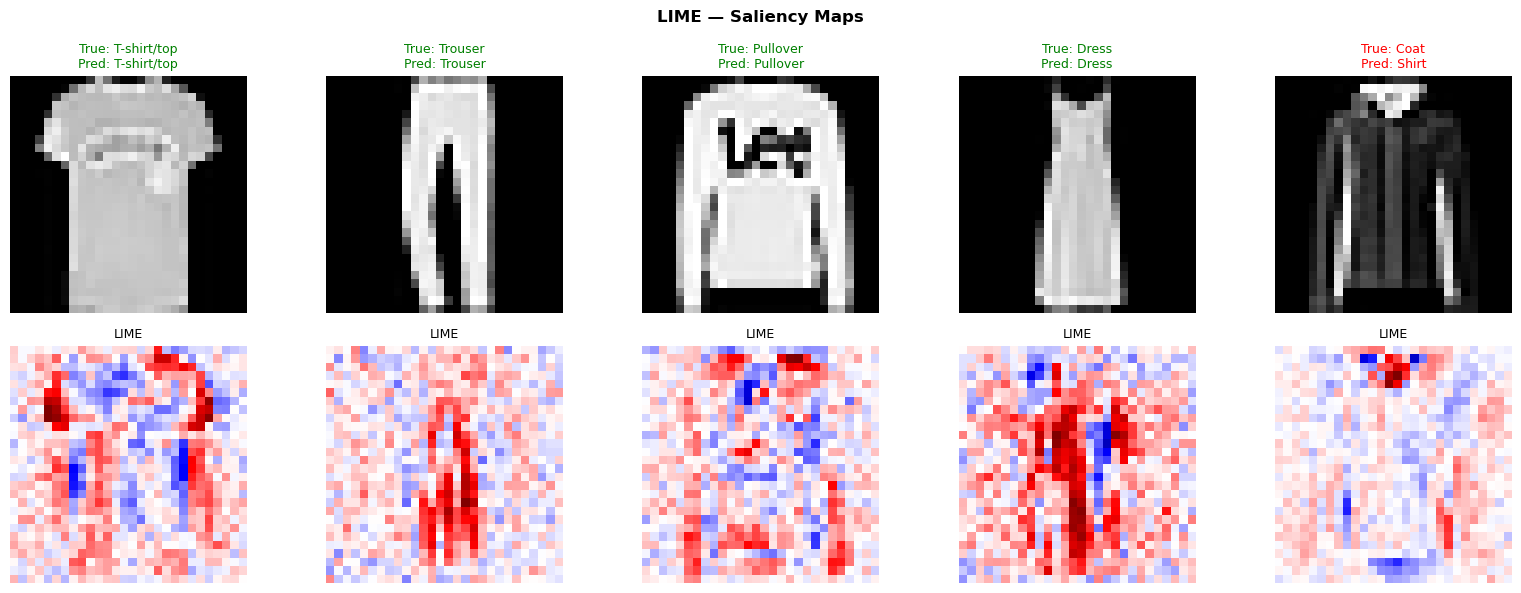

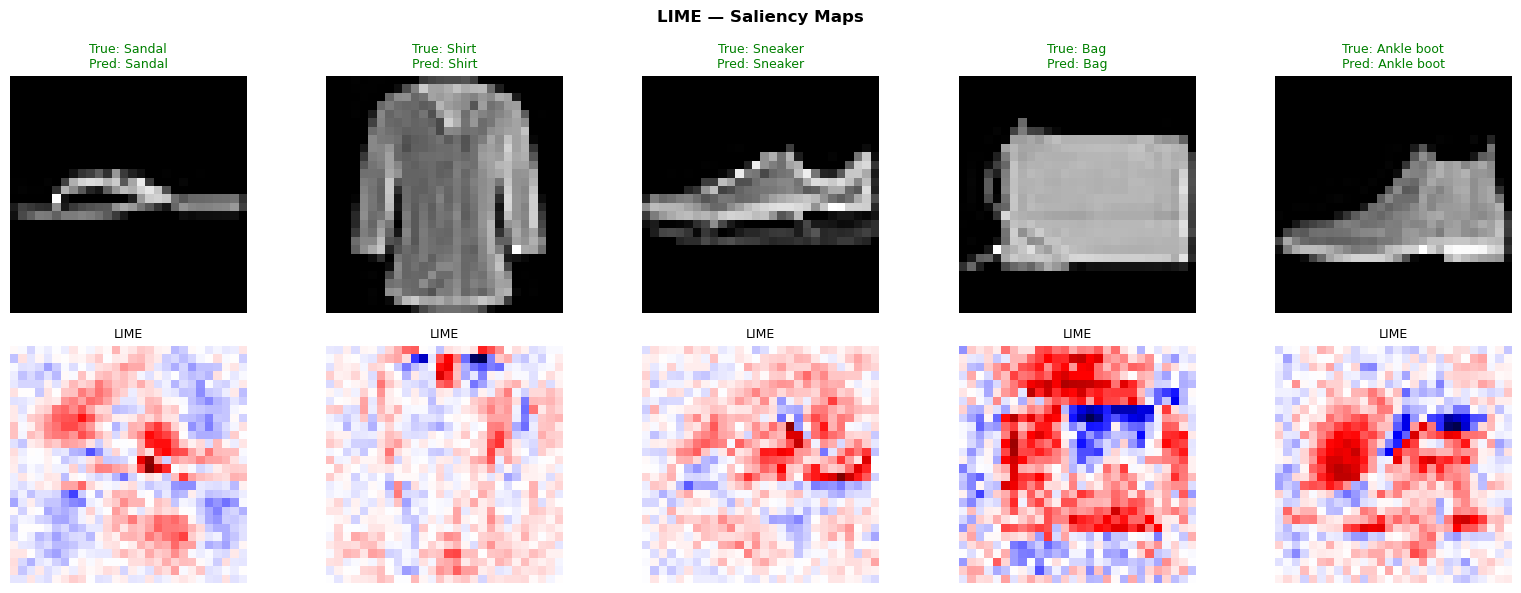

In [11]:
# ─── Visualise LIME saliency maps (from pre-computed attributions) ────────────
plot_saliency_maps(per_class_imgs, lime_attr_pc, targets_pc, per_class_labs,
                   FASHION_MNIST_CLASSES, 'LIME')

---
## 6. Side-by-Side Comparison

For each class: original image | SENN relevance bars | IG heatmap | LIME heatmap.

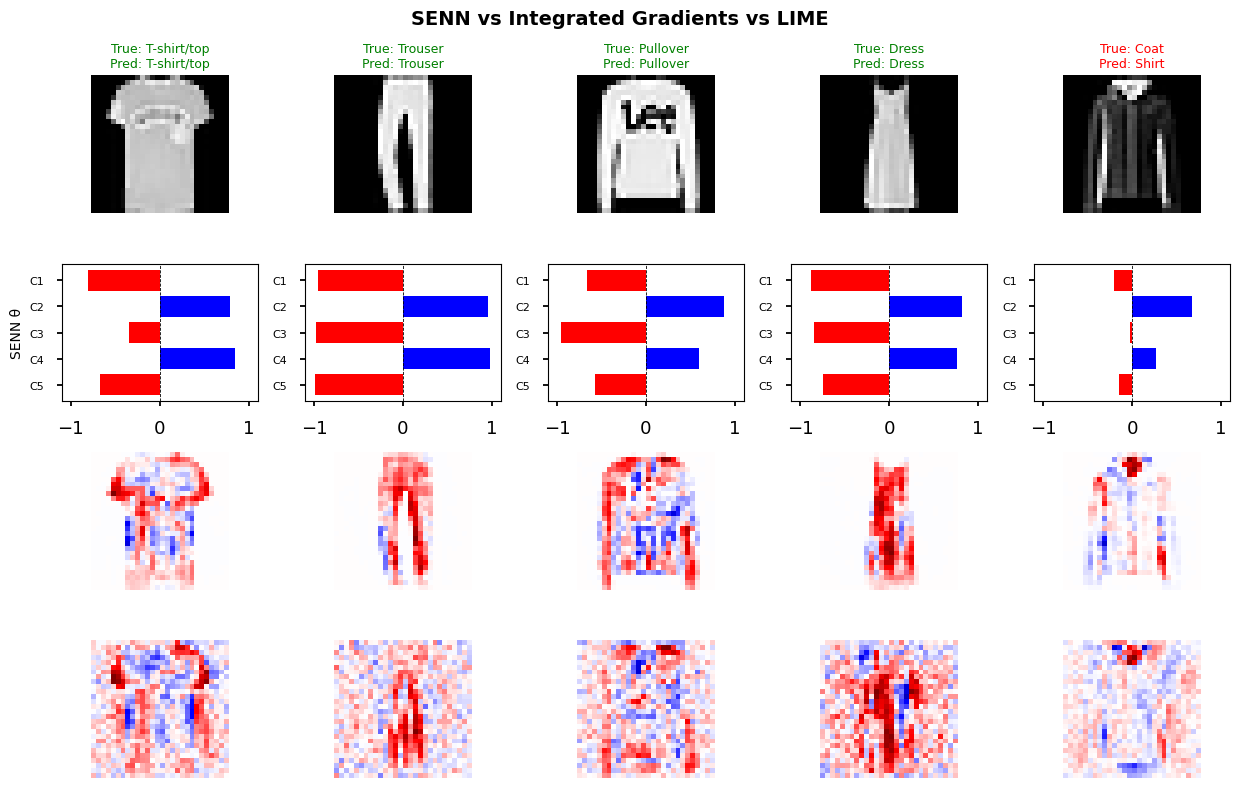

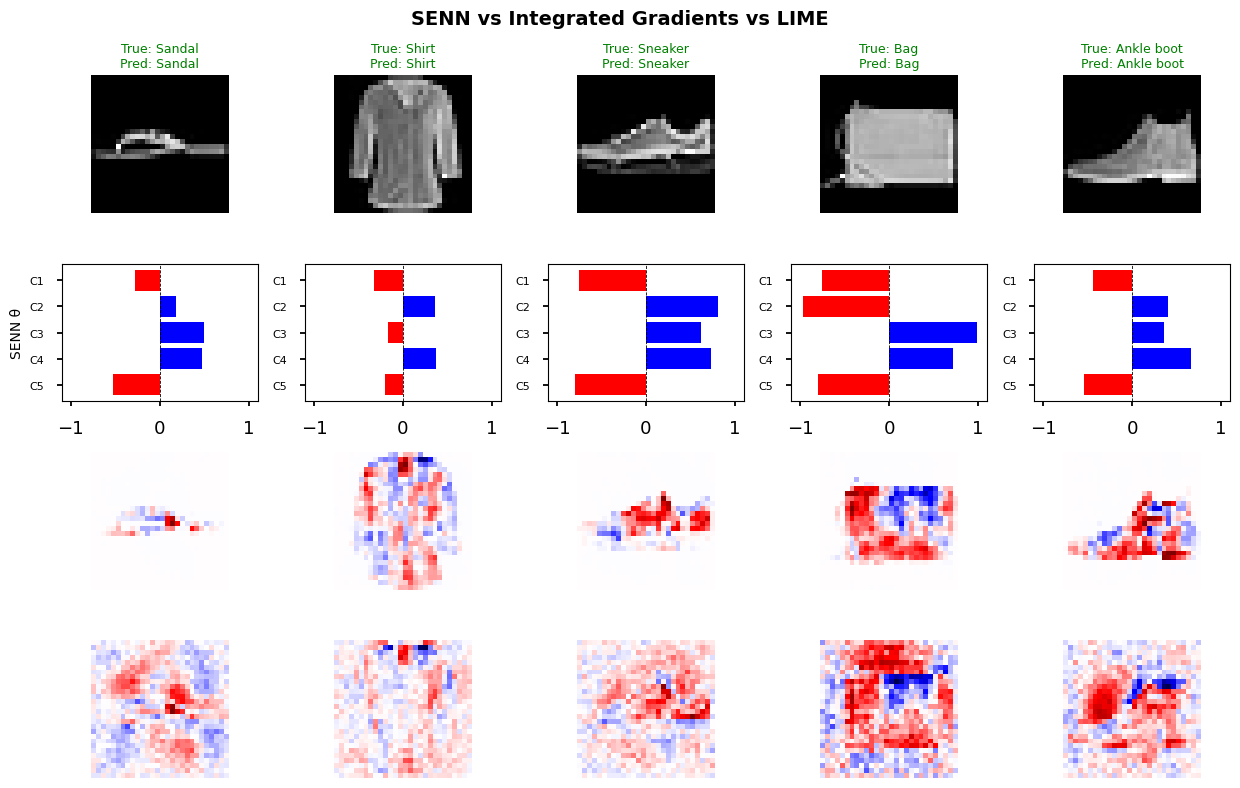

In [13]:
# ─── Three-way comparison ────────────────────────────────────────────────────
def plot_three_way_comparison(images, true_labels, y_pred, concepts, relevances,
                              ig_attrs, lime_attrs, class_names, ncols=5):
    n = len(images)
    pred_idx = y_pred.argmax(1)
    num_concepts = concepts.shape[1]
    y_labels = [f'C{j+1}' for j in range(num_concepts - 1, -1, -1)]
    
    for g in range((n + ncols - 1) // ncols):
        start = g * ncols
        end = min(start + ncols, n)
        nc = end - start
        
        # --- REDUCED FIGSIZE HERE ---
        # Changed from (3.5 * nc, 13) to (2.5 * nc, 8)
        fig, axes = plt.subplots(4, nc, figsize=(2.5 * nc, 8)) 
        
        if nc == 1:
            axes = axes[:, np.newaxis]
            
        for col, idx in enumerate(range(start, end)):
            true_lab = class_names[true_labels[idx].item()]
            pred_lab = class_names[pred_idx[idx].item()]
            color = 'green' if true_lab == pred_lab else 'red'
            
            # Row 0 — image
            axes[0, col].imshow(images[idx].squeeze().cpu(), cmap='gray')
            axes[0, col].set_title(f'True: {true_lab}\nPred: {pred_lab}', fontsize=9, color=color)
            axes[0, col].axis('off')
            
            # Row 1 — SENN relevances
            rs = relevances[idx, :, pred_idx[idx].item()].cpu()
            colors_r = ['b' if v > 0 else 'r' for v in rs.tolist()][::-1]
            axes[1, col].barh(np.arange(num_concepts), np.flip(rs.numpy()), color=colors_r)
            axes[1, col].set_yticks(np.arange(num_concepts))
            axes[1, col].set_yticklabels(y_labels, fontsize=8)
            axes[1, col].set_xlim(-1.1, 1.1)
            axes[1, col].axvline(0, color='k', lw=0.6, ls='--')
            if col == 0:
                axes[1, col].set_ylabel('SENN \u03b8', fontsize=10)
                
            # Row 2 — IG
            ig_map = ig_attrs[idx].sum(dim=0).cpu().numpy()
            abs_max_ig = max(abs(ig_map.min()), abs(ig_map.max())) + 1e-8
            axes[2, col].imshow(ig_map, cmap='seismic', vmin=-abs_max_ig, vmax=abs_max_ig)
            axes[2, col].axis('off')
            if col == 0:
                axes[2, col].set_ylabel('Int. Grad.', fontsize=10)
                
            # Row 3 — LIME
            lime_map = lime_attrs[idx].sum(dim=0).cpu().numpy()
            abs_max_lm = max(abs(lime_map.min()), abs(lime_map.max())) + 1e-8
            axes[3, col].imshow(lime_map, cmap='seismic', vmin=-abs_max_lm, vmax=abs_max_lm)
            axes[3, col].axis('off')
            if col == 0:
                axes[3, col].set_ylabel('LIME', fontsize=10)
                
        plt.suptitle('SENN vs Integrated Gradients vs LIME', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

plot_three_way_comparison(
    per_class_imgs, per_class_labs,
    y_pred_pc, concepts_pc, relevances_pc,
    ig_attr_pc, lime_attr_pc,
    FASHION_MNIST_CLASSES
)

---
## 7. Computational Cost Comparison

Timing from the pre-computed runs (wall-clock, full test set).

In [9]:
# ─── Computational cost (from saved meta) ────────────────────────────────────
# SENN cost: single forward pass on the test set for reference
import time
model.eval()
n_senn = 0
t0 = time.perf_counter()
with torch.no_grad():
    for x, _ in test_loader:
        _ = model(x.float().to(DEVICE))
        n_senn += len(x)
senn_time_per_sample = (time.perf_counter() - t0) / n_senn

ig_time_per_sample   = ig_meta['time_per_sample_s']
lime_time_per_sample = lime_meta['time_per_sample_s']

print(f'{"Method":<25} {"s / sample":>12} {"Fwd passes":>14}')
print('\u2500' * 55)
print(f'{"SENN (built-in)":<25} {senn_time_per_sample:>12.5f} {"1":>14}')
print(f'{"Integrated Gradients":<25} {ig_time_per_sample:>12.5f} {"~" + str(ig_meta.get("n_steps", 50)):>14}')
print(f'{"LIME":<25} {lime_time_per_sample:>12.5f} {"~" + str(lime_meta.get("n_lime_samples", 500)):>14}')

Method                      s / sample     Fwd passes
───────────────────────────────────────────────────────
SENN (built-in)                0.00027              1
Integrated Gradients           0.00112            ~50
LIME                           4.99774          ~2000


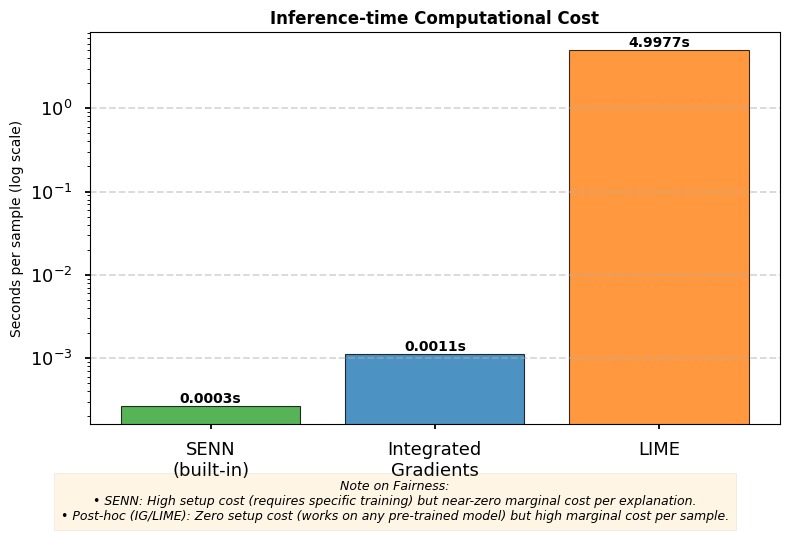

In [10]:
# ─── Cost bar chart ──────────────────────────────────────────────────────────
methods = ['SENN\n(built-in)', 'Integrated\nGradients', 'LIME']
times = [senn_time_per_sample, ig_time_per_sample, lime_time_per_sample]
colors = ['#2ca02c', '#1f77b4', '#ff7f0e']

fig, ax = plt.subplots(figsize=(8, 5)) # Leggermente più alto per far spazio alla nota
bars = ax.bar(methods, times, color=colors, edgecolor='black', linewidth=0.8, alpha=0.8)

ax.set_ylabel('Seconds per sample (log scale)', fontsize=10)
ax.set_title('Inference-time Computational Cost', fontweight='bold', fontsize=12)

# Aggiungiamo i valori sopra le barre
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{t:.4f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_yscale('log')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# --- NOTA SULLA FAIRNESS DEL CONFRONTO ---
note_text = (
    "Note on Fairness:\n"
    "• SENN: High setup cost (requires specific training) but near-zero marginal cost per explanation.\n"
    "• Post-hoc (IG/LIME): Zero setup cost (works on any pre-trained model) but high marginal cost per sample."
)
# Posizioniamo il box in basso a destra o sotto il grafico
plt.figtext(0.5, -0.05, note_text, ha="center", fontsize=9, 
            bbox={"facecolor":"orange", "alpha":0.1, "pad":5}, style='italic')

plt.tight_layout()
plt.show()

### 8. Faithfulness: Relative Ablation Test (Top vs Random)

Per valutare la *faithfulness* (fedeltà) delle spiegazioni, misuriamo quanto cala la confidenza del modello (Confidence Drop) quando rimuoviamo le feature ritenute più importanti.

Tuttavia, confrontare direttamente l'ablation dei **concetti latenti** (SENN) con l'ablation dei **pixel grezzi** (LIME/IG) genera un problema di discrepanza metodologica (effetto "Mele con Pere"). Oscurare i pixel inserendo il valore di background (nero normalizzato, $-0.8102$) crea immagini innaturali con artefatti visivi. Questo genera dati **Out-of-Distribution (OOD)** che confondono la rete neurale: la confidenza crolla non solo perché manca un'informazione vitale, ma perché l'immagine risulta "aliena". La SENN, azzerando i concetti nel suo spazio latente, non soffre di questo problema.

Per garantire un confronto *fair* (equo), abbiamo introdotto una **Metrica Relativa**:
$\text{Relative Drop} = \text{Drop}(\text{Top Features}) - \text{Drop}(\text{Random Features})$

In questo modo, filtriamo il "rumore" causato dall'effetto OOD:
* **Per LIME e IG:** Confrontiamo il calo di confidenza causato dall'oscuramento del Top-20% dei pixel rispetto all'oscuramento di un 20% di pixel casuali.
* **Per la SENN:** ordiniamo i concetti per contributo signed alla classe predetta ($h_i \cdot \theta_i$) e confrontiamo il drop del top-1 positivo con un concetto scelto casualmente.


**Nota di allineamento (aggiornata):**

In questa sezione usiamo il relative drop con confronto **Top vs Random** su quattro metodi:
- Integrated Gradients
- LIME
- SENN (solo θ, signed senza valore assoluto)
- SENN (h·θ, signed senza valore assoluto)

Per i due test SENN, il concetto random è sempre campionato **escludendo il concetto Top**.

In [11]:
# ─── SENN Relative Ablation Test (Top vs Random Concept) ─────────────────────
# ─── Variante A: SOLO θ (signed, no abs; random escluso top) ────────────────
model = trainer.model
model.eval()

all_senn_drop_top_theta = []
all_senn_drop_rand_theta = []
all_senn_drop_relative_theta = []

with torch.no_grad():
    for x, y in trainer.test_loader:
        x = x.float().to(DEVICE)
        y = y.long().to(DEVICE)

        y_pred, (concepts, relevances), _ = model(x)
        preds = y_pred.argmax(dim=1)

        probs_orig = torch.softmax(y_pred, dim=1)
        conf_orig = probs_orig[torch.arange(len(preds)), preds]

        concepts_abl_top = concepts.clone()
        concepts_abl_rand = concepts.clone()

        for i in range(len(x)):
            theta_i = relevances[i, :, preds[i].item()]
            top_concept = theta_i.argmax().item()
            concepts_abl_top[i, top_concept, :] = 0.0

            available_concepts = [c for c in range(concepts.shape[1]) if c != top_concept]
            rand_concept = available_concepts[torch.randint(0, len(available_concepts), (1,)).item()]
            concepts_abl_rand[i, rand_concept, :] = 0.0

        y_pred_top = model.aggregator(concepts_abl_top, relevances)
        conf_top = torch.softmax(y_pred_top, dim=1)[torch.arange(len(preds)), preds]

        y_pred_rand = model.aggregator(concepts_abl_rand, relevances)
        conf_rand = torch.softmax(y_pred_rand, dim=1)[torch.arange(len(preds)), preds]

        drop_top = (conf_orig - conf_top).cpu().numpy()
        drop_rand = (conf_orig - conf_rand).cpu().numpy()
        drop_relative = drop_top - drop_rand

        all_senn_drop_top_theta.extend(drop_top)
        all_senn_drop_rand_theta.extend(drop_rand)
        all_senn_drop_relative_theta.extend(drop_relative)

all_senn_drop_top_theta = np.array(all_senn_drop_top_theta)
all_senn_drop_rand_theta = np.array(all_senn_drop_rand_theta)
all_senn_drop_relative_theta = np.array(all_senn_drop_relative_theta)

# Alias legacy
all_senn_drop_top = all_senn_drop_top_theta
all_senn_drop_rand = all_senn_drop_rand_theta
all_senn_drop_relative = all_senn_drop_relative_theta

print(f"SENN (solo θ) Top Concept Drop    : {all_senn_drop_top_theta.mean():.4f}")
print(f"SENN (solo θ) Random Concept Drop : {all_senn_drop_rand_theta.mean():.4f}")
print(f"SENN (solo θ) Relative Drop       : {all_senn_drop_relative_theta.mean():.4f}")

SENN (solo θ) Top Concept Drop    : 0.0382
SENN (solo θ) Random Concept Drop : 0.0480
SENN (solo θ) Relative Drop       : -0.0098


In [12]:
# ─── SENN Relative Ablation Test (Top vs Random Concept) ─────────────────────
# ─── Variante B: h·θ (signed, no abs; random escluso top) ───────────────────
model.eval()

all_senn_drop_top_ht = []
all_senn_drop_rand_ht = []
all_senn_drop_relative_ht = []

with torch.no_grad():
    for x, y in trainer.test_loader:
        x = x.float().to(DEVICE)
        y = y.long().to(DEVICE)

        y_pred, (concepts, relevances), _ = model(x)
        preds = y_pred.argmax(dim=1)

        probs_orig = torch.softmax(y_pred, dim=1)
        conf_orig = probs_orig[torch.arange(len(preds)), preds]

        concepts_abl_top = concepts.clone()
        concepts_abl_rand = concepts.clone()

        for i in range(len(x)):
            # TOP: massimo contributo signed h·θ (senza valore assoluto)
            h_i = concepts[i].squeeze()
            theta_i = relevances[i, :, preds[i].item()]
            signed_contrib = h_i * theta_i
            top_concept = signed_contrib.argmax().item()
            concepts_abl_top[i, top_concept, :] = 0.0

            # RANDOM: campionato escludendo il top
            available_concepts = [c for c in range(concepts.shape[1]) if c != top_concept]
            rand_concept = available_concepts[torch.randint(0, len(available_concepts), (1,)).item()]
            concepts_abl_rand[i, rand_concept, :] = 0.0

        y_pred_top = model.aggregator(concepts_abl_top, relevances)
        conf_top = torch.softmax(y_pred_top, dim=1)[torch.arange(len(preds)), preds]

        y_pred_rand = model.aggregator(concepts_abl_rand, relevances)
        conf_rand = torch.softmax(y_pred_rand, dim=1)[torch.arange(len(preds)), preds]

        drop_top = (conf_orig - conf_top).cpu().numpy()
        drop_rand = (conf_orig - conf_rand).cpu().numpy()
        drop_relative = drop_top - drop_rand

        all_senn_drop_top_ht.extend(drop_top)
        all_senn_drop_rand_ht.extend(drop_rand)
        all_senn_drop_relative_ht.extend(drop_relative)

all_senn_drop_top_ht = np.array(all_senn_drop_top_ht)
all_senn_drop_rand_ht = np.array(all_senn_drop_rand_ht)
all_senn_drop_relative_ht = np.array(all_senn_drop_relative_ht)

print(f"SENN (h·θ) Top Concept Drop    : {all_senn_drop_top_ht.mean():.4f}")
print(f"SENN (h·θ) Random Concept Drop : {all_senn_drop_rand_ht.mean():.4f}")
print(f"SENN (h·θ) Relative Drop       : {all_senn_drop_relative_ht.mean():.4f}")

SENN (h·θ) Top Concept Drop    : 0.0798
SENN (h·θ) Random Concept Drop : 0.0369
SENN (h·θ) Relative Drop       : 0.0429


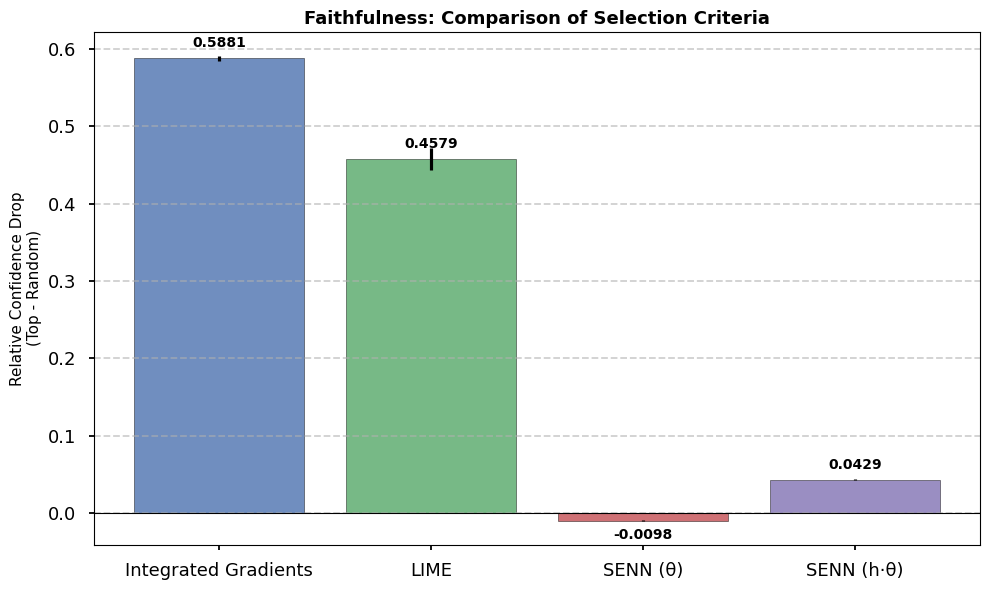


--- Riepilogo metriche di Ablation (Confronto θ vs h·θ) ---
              Method Feature Type  Top Drop (Abs)  Rand Drop (Abs) Relative Drop (±SE)
       SENN (only θ)     Concepts          0.0382           0.0480    -0.0098 ± 0.0007
          SENN (h·θ)     Concepts          0.0798           0.0369     0.0429 ± 0.0006
Integrated Gradients       Pixels          0.6693           0.0812     0.5881 ± 0.0033
                LIME       Pixels          0.5391           0.0811     0.4579 ± 0.0142


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ─── Preparazione Dati ───────────────────────────────────────────────────────
methods_list = [
    ('Integrated Gradients', ig_drop_relative, '#4C72B0'),
    ('LIME', lime_drop_relative, '#55A868'),
    ('SENN (θ)', all_senn_drop_relative_theta, '#C44E52'),
    ('SENN (h·θ)', all_senn_drop_relative_ht, '#8172B3')
]

labels = [m[0] for m in methods_list]
means = [m[1].mean() for m in methods_list]
stds = [m[1].std() / np.sqrt(len(m[1])) for m in methods_list]
colors = [m[2] for m in methods_list]

# ─── Plotting Relative Confidence Drop ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, means, yerr=stds, capsize=6, color=colors, alpha=0.8, edgecolor='black')

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_ylabel('Relative Confidence Drop\n(Top - Random)', fontsize=11)
ax.set_title('Faithfulness: Comparison of Selection Criteria', fontweight='bold', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    va = 'bottom' if yval > 0 else 'top'
    offset = 0.01 if yval > 0 else -0.01
    ax.text(bar.get_x() + bar.get_width()/2, yval + offset,
            f'{yval:.4f}', ha='center', va=va, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# ─── Tabella Finale Riepilogativa ────────────────────────────────────────────
summary_data = [
    {
        'Method': 'SENN (only θ)',
        'Feature Type': 'Concepts',
        'Top Drop (Abs)': all_senn_drop_top_theta.mean(),
        'Rand Drop (Abs)': all_senn_drop_rand_theta.mean(),
        'Relative Drop': means[2],
        'Std Error': stds[2]
    },
    {
        'Method': 'SENN (h·θ)',
        'Feature Type': 'Concepts',
        'Top Drop (Abs)': np.mean(all_senn_drop_top_ht),
        'Rand Drop (Abs)': np.mean(all_senn_drop_rand_ht),
        'Relative Drop': means[3],
        'Std Error': stds[3]
    },
    {
        'Method': 'Integrated Gradients',
        'Feature Type': 'Pixels',
        'Top Drop (Abs)': ig_drop_top.mean(),
        'Rand Drop (Abs)': ig_drop_rand.mean(),
        'Relative Drop': means[0],
        'Std Error': stds[0]
    },
    {
        'Method': 'LIME',
        'Feature Type': 'Pixels',
        'Top Drop (Abs)': lime_drop_top.mean(),
        'Rand Drop (Abs)': lime_drop_rand.mean(),
        'Relative Drop': means[1],
        'Std Error': stds[1]
    }
]

summary = pd.DataFrame(summary_data)
summary['Relative Drop (±SE)'] = summary.apply(
    lambda x: f"{x['Relative Drop']:.4f} ± {x['Std Error']:.4f}", axis=1
)

cols_to_show = ['Method', 'Feature Type', 'Top Drop (Abs)', 'Rand Drop (Abs)', 'Relative Drop (±SE)']
summary_print = summary[cols_to_show].round(4)

print("\n--- Riepilogo metriche di Ablation (Confronto θ vs h·θ) ---")
print(summary_print.to_string(index=False))

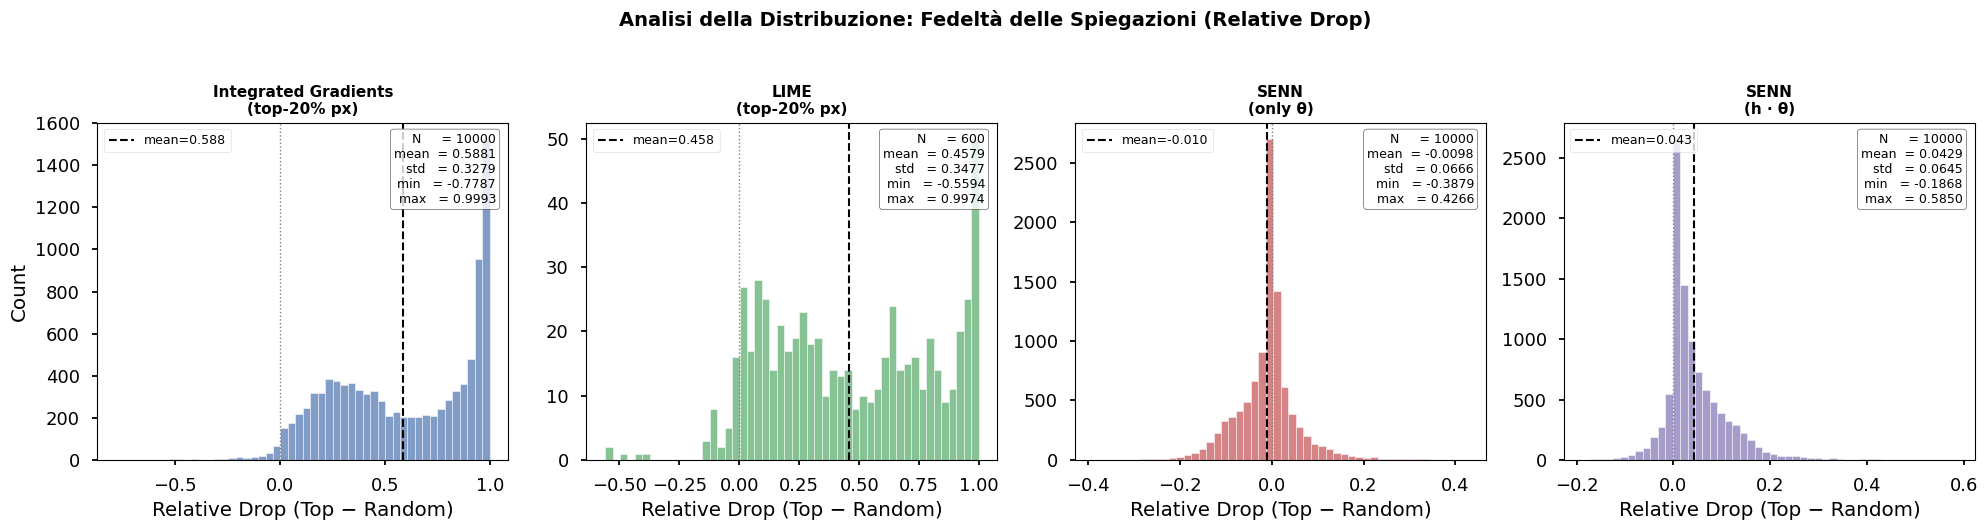

In [14]:
# ─── Distribuzione dei Relative Drops (Confronto Completo) ───────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

data = [
    (ig_drop_relative,             'Integrated Gradients\n(top-20% px)', '#4C72B0', len(ig_drop_relative)),
    (lime_drop_relative,           'LIME\n(top-20% px)',                 '#55A868', len(lime_drop_relative)),
    (all_senn_drop_relative_theta, 'SENN\n(only θ)',                     '#C44E52', len(all_senn_drop_relative_theta)),
    (all_senn_drop_relative_ht,    'SENN\n(h · θ)',                      '#8172B3', len(all_senn_drop_relative_ht)),
]

for ax, (arr, label, color, n) in zip(axes, data):
    ax.hist(arr, bins=50, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)

    mean_val = np.mean(arr)
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'mean={mean_val:.3f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=1)

    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('Relative Drop (Top − Random)')
    if ax == axes[0]:
        ax.set_ylabel('Count')

    stats_text = (f'N     = {n}\n'
                  f'mean  = {mean_val:.4f}\n'
                  f'std   = {np.std(arr):.4f}\n'
                  f'min   = {np.min(arr):.4f}\n'
                  f'max   = {np.max(arr):.4f}')

    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(fontsize=9, loc='upper left')

plt.suptitle('Analisi della Distribuzione: Fedeltà delle Spiegazioni (Relative Drop)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
### 8b. Faithfulness: Spearman Correlation (Importance Rank vs Actual Drop)

A more principled faithfulness test — directly motivated by the paper — measures the
**correlation** between the estimated importance of each feature and the actual confidence
drop when that feature is removed.

- **SENN:** for each sample, ablate each of the 5 concepts one at a time → 5 actual drops.
  Compute Spearman ρ between signed contribution `hᵢ·θᵢ` (estimated importance for the predicted class) and the 5 drops.
- **IG / LIME:** split pixels into 5 quintiles by `|attribution|`, ablate each quintile
  separately → 5 actual drops. Compute Spearman ρ between mean attribution in each quintile
  and the 5 drops.
- **Random baseline:** same quintile procedure but with shuffled (random) attributions.
  Expected ρ ≈ 0 because random scores carry no true importance information.

In [19]:
from scipy.stats import spearmanr
# ─── SENN Spearman: tre varianti di importanza ───────────────────────────────
#
# Variante 1: |h|     — presenza del concetto, ignora la rilevanza
# Variante 2: |θ|     — rilevanza pura, ignora quanto il concetto è attivo
# Variante 3: θ·h     — contributo SIGNED al logit (fix: niente abs!)
#
# NOTA sul segno: usare |θ·h| metterebbe in cima sia contributi positivi
# che negativi. Rimuovere un contributo negativo FA SALIRE la confidenza
# → drop negativo → Spearman artificialmente bassa.
# θ·h signed seleziona sempre il maggiore contributo positivo → drop atteso +.

model.eval()
senn_spearman_h     = []   # |h| solo
senn_spearman_theta = []   # |θ| solo
senn_spearman_th_h  = []   # θ·h signed ← versione corretta

with torch.no_grad():
    for x, _ in trainer.test_loader:
        x      = x.float().to(DEVICE)
        y_pred, (concepts, relevances), _ = model(x)
        preds     = y_pred.argmax(dim=1)
        probs     = torch.softmax(y_pred, dim=1)
        conf_orig = probs[torch.arange(len(preds)), preds]

        num_concepts = concepts.shape[1]

        for i in range(len(x)):
            h_i  = concepts[i].squeeze().cpu().numpy()              # (C,)
            th_i = relevances[i, :, preds[i].item()].cpu().numpy()  # (C,)

            imp_h    = (h_i)        # variante 1, non sicurissimo che non ci vada np.abs()
            imp_th   = (th_i)       # variante 2
            imp_th_h = th_i * h_i         # variante 3 — SIGNED, niente abs

            drops = []
            for j in range(num_concepts):
                c_abl = concepts[i].clone().unsqueeze(0)
                c_abl[0, j, :] = 0.0
                y_abl    = model.aggregator(c_abl, relevances[i].unsqueeze(0))
                conf_abl = torch.softmax(y_abl, dim=1)[0, preds[i]].item()
                drops.append(conf_orig[i].item() - conf_abl)

            drops = np.array(drops)

            if drops.std() > 1e-8:
                if imp_h.std() > 1e-8:
                    senn_spearman_h.append(spearmanr(imp_h, drops).statistic)
                if imp_th.std() > 1e-8:
                    senn_spearman_theta.append(spearmanr(imp_th, drops).statistic)
                if imp_th_h.std() > 1e-8:
                    senn_spearman_th_h.append(spearmanr(imp_th_h, drops).statistic)

senn_spearman_h     = np.array(senn_spearman_h)
senn_spearman_theta = np.array(senn_spearman_theta)
senn_spearman_th_h  = np.array(senn_spearman_th_h)

print("SENN Spearman ρ — confronto varianti")
print(f"  h    N={len(senn_spearman_h):>6},  mean={senn_spearman_h.mean():.4f},  std={senn_spearman_h.std():.4f}")
print(f"  θ    N={len(senn_spearman_theta):>6},  mean={senn_spearman_theta.mean():.4f},  std={senn_spearman_theta.std():.4f}")
print(f"  θ·h    N={len(senn_spearman_th_h):>6},  mean={senn_spearman_th_h.mean():.4f},  std={senn_spearman_th_h.std():.4f}")

SENN Spearman ρ — confronto varianti
  h    N= 10000,  mean=-0.0916,  std=0.5154
  θ    N= 10000,  mean=-0.0366,  std=0.5134
  θ·h    N= 10000,  mean=0.6975,  std=0.3606


In [16]:
# ─── IG / LIME Spearman + correct Random baseline (quintile-based) ────────────
#
# Why the earlier random baseline was WRONG:
#   The previous code sampled d_top and d_rand independently from the IG drop
#   distributions.  Because IG is faithful, E[ig_drop_top] >> E[ig_drop_rand],
#   so the mean of their difference ≈ the IG relative drop itself — not 0.
#
# Correct approach — shuffle the attribution map per image:
#   Shuffled "top-20%" ≈ any random 20% → relative drop ≈ 0 by construction.
#
# For Spearman we use 5 quintiles (bins) of pixels by |attribution| to match
# SENN's 5 concepts, giving 5 (importance, drop) pairs per image.

class SENNWrapper(torch.nn.Module):
    """Thin wrapper that exposes only logits, as required for pixel ablation."""
    def __init__(self, senn_model):
        super().__init__()
        self.senn = senn_model
    def forward(self, x):
        logits, _, _ = self.senn(x)
        return logits

wrapper = SENNWrapper(model).to(DEVICE)
wrapper.eval()

FILL_VALUE = -0.8102   # normalised black pixel: (0 - 0.2860) / 0.3530
N_BINS     = 5         # match SENN's number of concepts
N_EVAL     = min(600, len(lime_labels))   # cap for speed; LIME already limited to 600
TOP_FRAC   = 0.20
N_TOP      = int(28 * 28 * TOP_FRAC)

# Collect the first N_EVAL test images in loader order (shuffle=False)
_imgs = []
for x, _ in test_loader:
    _imgs.append(x.float())
    if sum(len(b) for b in _imgs) >= N_EVAL:
        break
eval_images = torch.cat(_imgs, dim=0)[:N_EVAL]   # (N_EVAL, 1, 28, 28)

np.random.seed(42)

def quintile_spearman(images, attributions, predictions, shuffle_attr=False):
    """
    For each image: bin pixels into N_BINS quintiles by |attribution|,
    ablate each bin, measure confidence drop, compute Spearman ρ between
    mean |attribution| in the bin and the measured drop.
    Returns array of per-sample correlations.
    """
    correlations = []
    n = len(images)
    bin_size = (28 * 28) // N_BINS

    for i in range(n):
        img  = images[i].unsqueeze(0).to(DEVICE)
        pred = predictions[i].item()
        attr = attributions[i].squeeze().abs().numpy().flatten()   # (784,)

        if shuffle_attr:
            attr = np.random.permutation(attr)

        sorted_idx = np.argsort(attr)   # ascending → quintile 0 = least important

        with torch.no_grad():
            conf_orig = torch.softmax(wrapper(img), dim=1)[0, pred].item()

        bin_drops, bin_importance = [], []
        for b in range(N_BINS):
            start = b * bin_size
            end   = (b + 1) * bin_size if b < N_BINS - 1 else 784
            pix   = sorted_idx[start:end]

            img_abl = img.clone().reshape(1, -1)
            img_abl[0, pix] = FILL_VALUE
            img_abl = img_abl.reshape(1, 1, 28, 28)

            with torch.no_grad():
                conf_abl = torch.softmax(wrapper(img_abl), dim=1)[0, pred].item()

            bin_drops.append(conf_orig - conf_abl)
            bin_importance.append(attr[pix].mean())

        bin_drops      = np.array(bin_drops)
        bin_importance = np.array(bin_importance)

        if bin_drops.std() > 1e-8 and bin_importance.std() > 1e-8:
            rho, _ = spearmanr(bin_importance, bin_drops)
            correlations.append(rho)

    return np.array(correlations)


print("Computing IG quintile Spearman…")
ig_spearman   = quintile_spearman(eval_images, ig_attrs[:N_EVAL],   ig_preds[:N_EVAL])
print("Computing LIME quintile Spearman…")
lime_spearman = quintile_spearman(eval_images, lime_attrs,           lime_preds)
print("Computing Random baseline quintile Spearman…")
rand_spearman = quintile_spearman(eval_images, ig_attrs[:N_EVAL],   ig_preds[:N_EVAL],
                                  shuffle_attr=True)

print()
print(f"IG   Spearman ρ  N={len(ig_spearman):>5},  mean={ig_spearman.mean():.4f},  std={ig_spearman.std():.4f}")
print(f"LIME Spearman ρ  N={len(lime_spearman):>5},  mean={lime_spearman.mean():.4f},  std={lime_spearman.std():.4f}")
print(f"Rand Spearman ρ  N={len(rand_spearman):>5},  mean={rand_spearman.mean():.4f},  std={rand_spearman.std():.4f}  ← expected ≈0")

Computing IG quintile Spearman…
Computing LIME quintile Spearman…
Computing Random baseline quintile Spearman…

IG   Spearman ρ  N=  600,  mean=0.6831,  std=0.3579
LIME Spearman ρ  N=  600,  mean=0.6537,  std=0.3684
Rand Spearman ρ  N=  600,  mean=0.0290,  std=0.5029  ← expected ≈0


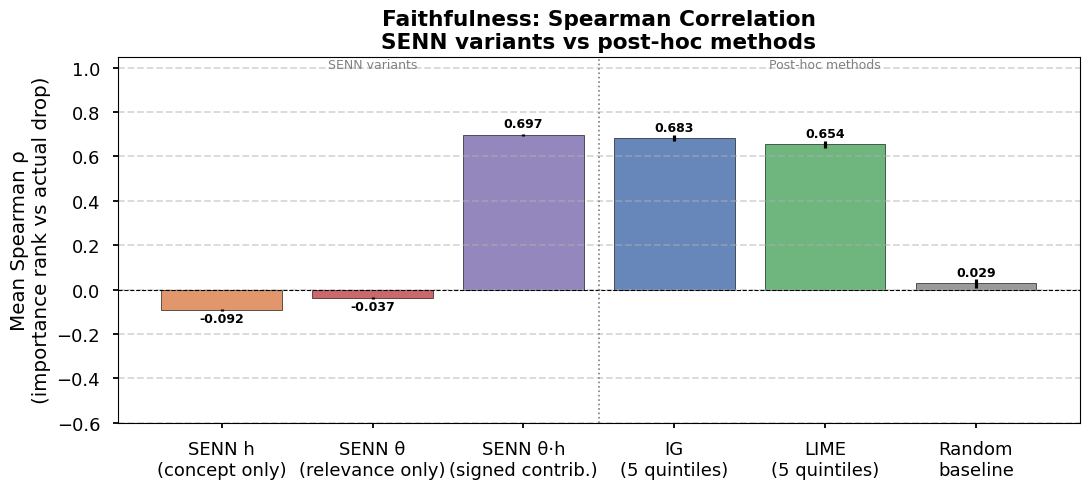

                     Method  Mean ρ  Std ρ  N samples
     SENN h\n(concept only) -0.0916 0.5154      10000
   SENN θ\n(relevance only) -0.0366 0.5134      10000
SENN θ·h\n(signed contrib.)  0.6975 0.3606      10000
          IG\n(5 quintiles)  0.6831 0.3579        600
        LIME\n(5 quintiles)  0.6537 0.3684        600
           Random\nbaseline  0.0290 0.5029        600


In [20]:
# ─── Spearman ρ bar chart — SENN (3 varianti) + IG + LIME + Random ───────────

_labels = [
    'SENN h\n(concept only)',
    'SENN θ\n(relevance only)',
    'SENN θ·h\n(signed contrib.)',
    'IG\n(5 quintiles)',
    'LIME\n(5 quintiles)',
    'Random\nbaseline',
]
_data = [
    senn_spearman_h,
    senn_spearman_theta,
    senn_spearman_th_h,
    ig_spearman,
    lime_spearman,
    rand_spearman,
]
_means  = [d.mean() for d in _data]
_sems   = [d.std() / np.sqrt(len(d)) for d in _data]
_colors = ['#dd8452', '#c44e52', '#8172b2',   # SENN: arancio, rosso, viola
           '#4c72b0', '#55a868',               # IG blu, LIME verde
           '#888888']                          # random grigio

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(_labels, _means, yerr=_sems, capsize=5,
              color=_colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean Spearman ρ\n(importance rank vs actual drop)')
ax.set_title('Faithfulness: Spearman Correlation\n'
             'SENN variants vs post-hoc methods', fontweight='bold')
ax.set_ylim(-0.6, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar, m in zip(bars, _means):
    yoffset = 0.02 if m >= 0 else -0.07
    ax.text(bar.get_x() + bar.get_width() / 2, m + yoffset,
            f'{m:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Linea verticale che separa SENN dai metodi post-hoc
ax.axvline(2.5, color='gray', linestyle=':', linewidth=1.2)
ax.text(1.0, 1.00, 'SENN variants', ha='center', color='gray', fontsize=9)
ax.text(4.0, 1.00, 'Post-hoc methods', ha='center', color='gray', fontsize=9)

plt.tight_layout()
plt.show()

# ─── Tabella riassuntiva ──────────────────────────────────────────────────────
spearman_df = pd.DataFrame({
    'Method':    _labels,
    'Mean ρ':    [round(d.mean(), 4) for d in _data],
    'Std ρ':     [round(d.std(),  4) for d in _data],
    'N samples': [len(d)             for d in _data],
})
print(spearman_df.to_string(index=False))

In [18]:
# ─── Spearman ρ comparison bar chart ─────────────────────────────────────────
_labels = ['SENN\n(5 concepts)', 'IG\n(5 quintiles)', 'LIME\n(5 quintiles)', 'Random\nbaseline']
_means  = [senn_spearman.mean(), ig_spearman.mean(), lime_spearman.mean(), rand_spearman.mean()]
_sems   = [senn_spearman.std() / np.sqrt(len(senn_spearman)),
           ig_spearman.std()   / np.sqrt(len(ig_spearman)),
           lime_spearman.std() / np.sqrt(len(lime_spearman)),
           rand_spearman.std() / np.sqrt(len(rand_spearman))]
_colors = ['#C44E52', '#4C72B0', '#55A868', '#888888']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(_labels, _means, yerr=_sems, capsize=5,
              color=_colors, alpha=0.85, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean Spearman ρ\n(importance rank vs actual drop)')
ax.set_title('Faithfulness: Spearman Correlation', fontweight='bold')
ax.set_ylim(-0.2, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar, m in zip(bars, _means):
    yoffset = 0.02 if m >= 0 else -0.05
    ax.text(bar.get_x() + bar.get_width() / 2, m + yoffset,
            f'{m:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

# ─── Spearman summary table ───────────────────────────────────────────────────
spearman_df = pd.DataFrame({
    'Method':     ['SENN (5 concepts)', 'IG (5 quintiles)', 'LIME (5 quintiles)', 'Random baseline'],
    'Mean ρ':     [senn_spearman.mean(), ig_spearman.mean(), lime_spearman.mean(), rand_spearman.mean()],
    'Std ρ':      [senn_spearman.std(),  ig_spearman.std(),  lime_spearman.std(),  rand_spearman.std()],
    'N samples':  [len(senn_spearman),   len(ig_spearman),   len(lime_spearman),   len(rand_spearman)],
}).round(4)
print(spearman_df.to_string(index=False))

NameError: name 'senn_spearman' is not defined

---
## 9. Discussion

### Faithfulness — Relative Ablation
Nel test SENN aggiornato, il concetto "Top" è selezionato usando il **contributo signed**
alla classe predetta ($h_i \cdot \theta_i$), non il valore assoluto di $\theta_i$.
Questo evita il bias concettuale in cui concetti con contributo fortemente negativo vengono
considerati "più importanti" solo per magnitudine e, se ablati, aumentano la confidenza.

### Faithfulness — Spearman Correlation (Section 8b)
Il test Spearman SENN usa ora come stima di importanza il contributo signed $h_i \cdot \theta_i$,
correlato con il drop reale ottenuto ablando un concetto alla volta.
IG/LIME restano valutati con procedura a quintili in pixel-space.

### Qualitative comparison
La visualizzazione a tre vie (Section 6) mostra che IG tende a mappe più nitide e allineate ai contorni,
mentre LIME produce evidenze più grossolane.
Le spiegazioni SENN restano nel latent/concept space e non sono pixel-wise.

### Computational cost
SENN produce spiegazioni nel singolo forward pass,
IG richiede più forward pass (integrazione),
LIME è il più costoso perché perturbation-based.

---
## 10. Summary Table

In [27]:
# ─── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Method':          ['SENN (built-in)', 'Integrated Gradients', 'LIME'],
    'Type':            ['Self-explaining', 'Post-hoc (gradient)', 'Post-hoc (perturbation)'],
    'Time/sample (s)': [senn_time_per_sample, ig_time_per_sample, lime_time_per_sample],
    'Fwd passes':      [1, ig_meta.get('n_steps', 50), lime_meta.get('n_lime_samples', 500)],
    'Top Drop (mean)': [all_senn_drop_top.mean(), ig_drop_top.mean(), lime_drop_top.mean()],
    'Rel. Drop (mean)':[all_senn_drop_relative.mean(), ig_drop_relative.mean(), lime_drop_relative.mean()],
    'Rel. Drop (std)': [all_senn_drop_relative.std(), ig_drop_relative.std(), lime_drop_relative.std()],
    'N samples':       [len(all_senn_drop_relative), len(ig_drop_relative), len(lime_drop_relative)],
})
summary = summary.round(4)
print(summary.to_string(index=False))
summary

              Method                    Type  Time/sample (s)  Fwd passes  Top Drop (mean)  Rel. Drop (mean)  Rel. Drop (std)  N samples
     SENN (built-in)         Self-explaining           0.0003           1           0.0382           -0.0098           0.0666      10000
Integrated Gradients     Post-hoc (gradient)           0.0011          50           0.6693            0.5881           0.3279      10000
                LIME Post-hoc (perturbation)           4.9977        2000           0.5391            0.4579           0.3477        600


,Method,Type,Time/sample (s),Fwd passes,Top Drop (mean),Rel. Drop (mean),Rel. Drop (std),N samples
0,SENN (built-in),Self-explaining,0.0003,1,0.0382,-0.0098,0.0666,10000
1,Integrated Gradients,Post-hoc (gradient),0.0011,50,0.6693,0.5881,0.3279,10000
2,LIME,Post-hoc (perturbation),4.9977,2000,0.5391,0.4579,0.3477,600


nuova aggiunta di claude

In [22]:
# ─── Preparazione dati per Ablazione ──────────────────────────────────────────

all_images_list = []
all_concepts_list = []

print("Estrazione immagini e calcolo medie dei concetti...")

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(DEVICE)
        all_images_list.append(x.cpu()) # Salviamo in CPU per non saturare la GPU
        
        # Opzionale: se ti serve H_FILL_MEAN e non l'hai ancora calcolato:
        _, (concepts, _), _ = model(x)
        # concepts ha forma (batch, num_concepts, 1) o (batch, num_concepts)
        all_concepts_list.append(concepts.squeeze(-1).cpu())

# Concateniamo tutto in un unico tensore
all_images = torch.cat(all_images_list, dim=0)
all_concepts = torch.cat(all_concepts_list, dim=0)

# Calcoliamo la media empirica di ogni concetto (H_FILL_MEAN)
# Questo serve per la tua Cella C (il "fill corretto")
H_FILL_MEAN = all_concepts.mean(dim=0)

print(f"Completato: {len(all_images)} immagini pronte in 'all_images'")
print(f"H_FILL_MEAN calcolato per {len(H_FILL_MEAN)} concetti.")

Estrazione immagini e calcolo medie dei concetti...
Completato: 10000 immagini pronte in 'all_images'
H_FILL_MEAN calcolato per 5 concetti.


In [33]:
# ── Cella C: Ablazione SENN con fill = media empirica vs fill = 0.0 ────────
#
# Se h non è centrato in zero, azzerare h_j manda il modello OOD.
# ANALOGIA: è come testare una ricetta togliendo il sale e mettendo
# ghiaccio al suo posto, invece di non mettere nulla.
# Il fill corretto è la media empirica del concept j sul test set.
#
# H_FILL_MEAN è stato calcolato nella Cella A.

model.eval()
drops_zero_fill = []
drops_mean_fill = []

N_SAMPLES = min(500, len(all_images))

with torch.no_grad():
    for i in range(N_SAMPLES):
        img = all_images[i].unsqueeze(0).to(DEVICE)
        y_pred, (concepts, relevances), _ = model(img)

        pred_class = y_pred.argmax(dim=1).item()
        conf_orig  = torch.softmax(y_pred, dim=1)[0, pred_class].item()

        h_i  = concepts[0, :, 0].cpu().numpy()
        th_i = relevances[0, :, pred_class].cpu().numpy()
        th_h = th_i * h_i                        # signed

        # Concept più importante secondo θ·h signed
        top_j = int(np.argmax(th_h))

        # Fill = 0.0
        c_z = concepts.clone()
        c_z[0, top_j, 0] = 0.0
        # RIMOSSO .squeeze(-1) qui sotto:
        y_z = model.aggregator(c_z, relevances) 
        drop_z = conf_orig - torch.softmax(y_z, dim=1)[0, pred_class].item()
        drops_zero_fill.append(drop_z)

        # Fill = media empirica del concept j
        c_m = concepts.clone()
        c_m[0, top_j, 0] = H_FILL_MEAN[top_j].item()
        # RIMOSSO .squeeze(-1) qui sotto:
        y_m = model.aggregator(c_m, relevances) 
        drop_m = conf_orig - torch.softmax(y_m, dim=1)[0, pred_class].item()
        drops_mean_fill.append(drop_m)

print("="*55)
print("ABLAZIONE top concept: fill=0.0 vs fill=media empirica")
print("="*55)
print(f"Drop medio  fill=0.0  : {np.mean(drops_zero_fill):.4f}")
print(f"Drop medio  fill=mean : {np.mean(drops_mean_fill):.4f}")
print("="*55)
print("Se i due valori differiscono molto → 0.0 era OOD.")
print("Usa fill=mean per l'analisi di faithfulness definitiva.")

ABLAZIONE top concept: fill=0.0 vs fill=media empirica
Drop medio  fill=0.0  : 0.0785
Drop medio  fill=mean : 0.0220
Se i due valori differiscono molto → 0.0 era OOD.
Usa fill=mean per l'analisi di faithfulness definitiva.


Analisi su 1000 campioni...


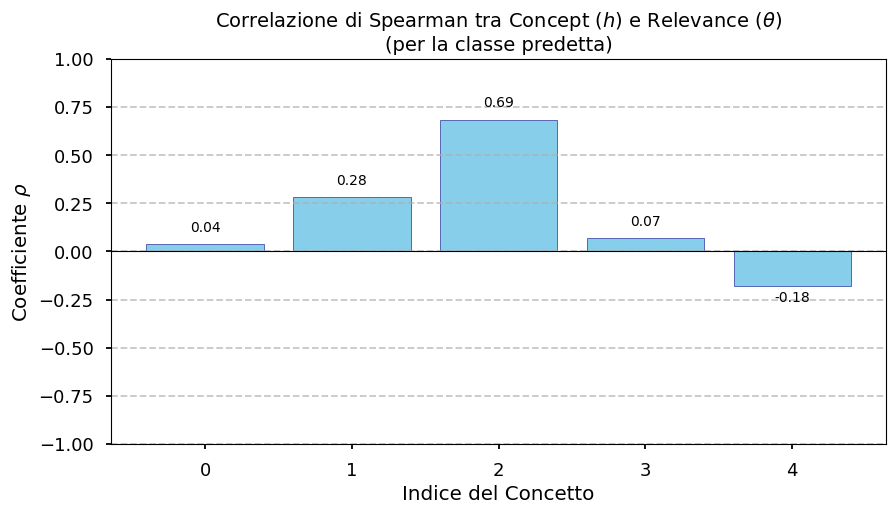

Interpretazione:
Media delle correlazioni: 0.1793


In [23]:
# ─── Analisi della Correlazione h vs θ ───────────────────────────────────────
from scipy.stats import spearmanr

# 1. Raccogliamo i dati (usiamo un subset per velocità o tutto all_images)
N_CORR = min(1000, len(all_images))
all_h = []
all_th = []

print(f"Analisi su {N_CORR} campioni...")

with torch.no_grad():
    for i in range(N_CORR):
        img = all_images[i].unsqueeze(0).to(DEVICE)
        y_pred, (concepts, relevances), _ = model(img)
        
        pred_class = y_pred.argmax(dim=1).item()
        
        # Estraiamo h e theta per la classe predetta
        # h: (1, C, 1) -> (C,)
        # relevances: (1, C, K) -> prendiamo solo la colonna della pred_class
        h_i = concepts[0, :, 0].cpu().numpy()
        th_i = relevances[0, :, pred_class].cpu().numpy()
        
        all_h.append(h_i)
        all_th.append(th_i)

all_h = np.array(all_h)   # Shape: (N, Num_Concepts)
all_th = np.array(all_th) # Shape: (N, Num_Concepts)

# 2. Calcolo correlazione per ogni concetto
concept_correlations = []
num_concepts = all_h.shape[1]

for j in range(num_concepts):
    h_j = all_h[:, j]
    th_j = all_th[:, j]
    
    # Calcoliamo Spearman
    if np.std(h_j) > 1e-8 and np.std(th_j) > 1e-8:
        corr, _ = spearmanr(h_j, th_j)
    else:
        corr = 0.0
    concept_correlations.append(corr)

# 3. Visualizzazione
plt.figure(figsize=(10, 5))
bars = plt.bar(range(num_concepts), concept_correlations, color='skyblue', edgecolor='navy')
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Correlazione di Spearman tra Concept ($h$) e Relevance ($\\theta$)\n(per la classe predetta)", fontsize=14)
plt.xlabel("Indice del Concetto")
plt.ylabel("Coefficiente $\\rho$")
plt.xticks(range(num_concepts))
plt.ylim(-1, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Aggiungi i valori sopra le barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.05 if yval > 0 else -0.1), 
             f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

plt.show()

print("Interpretazione:")
print(f"Media delle correlazioni: {np.mean(concept_correlations):.4f}")